In [36]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from rdkit import Chem
from rdkit.Chem import Descriptors, Draw
from rdkit.Chem.Draw import IPythonConsole
IPythonConsole.ipython_useSVG = True

In [37]:
generated_no_mw = pd.read_csv("../logs/s_aureus_solubility_sa/final/molecules.csv")
generated_mw_300_1000 = pd.read_csv("../logs/s_aureus_solubility_sa_mw_300_1000/final/molecules.csv")
generated_mw_200_600 = pd.read_csv("../logs/s_aureus_solubility_sa_mw_200_600/final/molecules.csv")

In [38]:
generated_no_mw["molecular_weight"] = [Descriptors.MolWt(Chem.MolFromSmiles(smiles)) for smiles in generated_no_mw["smiles"]]

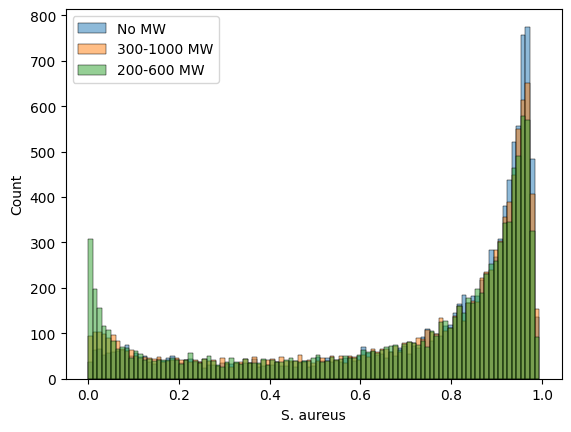

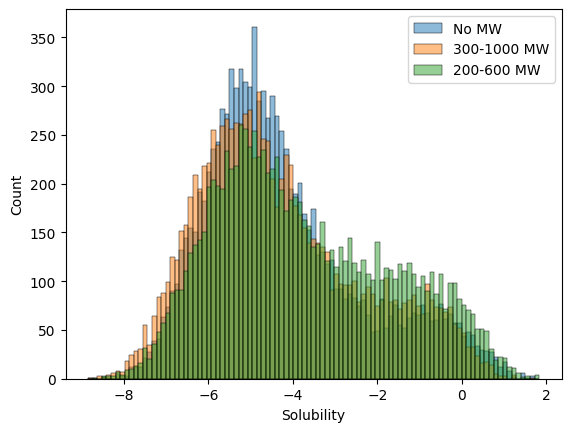

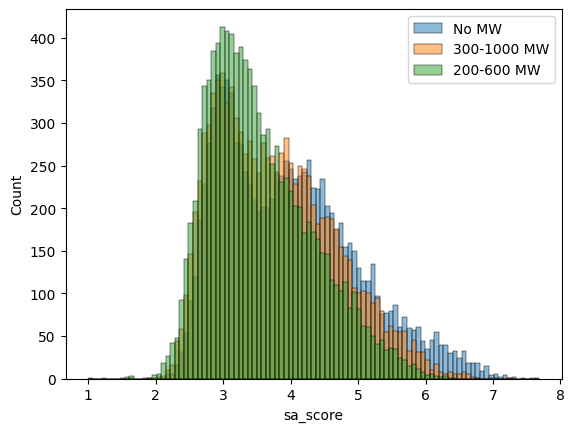

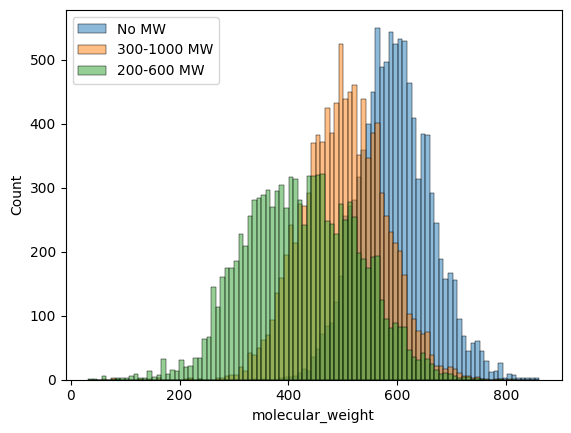

In [39]:
for prop in ["S. aureus", "Solubility", "sa_score", "molecular_weight"]:
    min_val = min(generated_no_mw[prop].min(), generated_mw_200_600[prop].min(), generated_mw_300_1000[prop].min())
    max_val = max(generated_no_mw[prop].max(), generated_mw_200_600[prop].max(), generated_mw_300_1000[prop].max())
    bins = np.linspace(min_val, max_val, 100)

    sns.histplot(generated_no_mw[prop], bins=bins, label="No MW", alpha=0.5)
    sns.histplot(generated_mw_300_1000[prop], bins=bins, label="300-1000 MW", alpha=0.5)
    sns.histplot(generated_mw_200_600[prop], bins=bins, label="200-600 MW", alpha=0.5)
    plt.legend()
    plt.show()

Data size = 10,304
Data size after filtering = 5,521


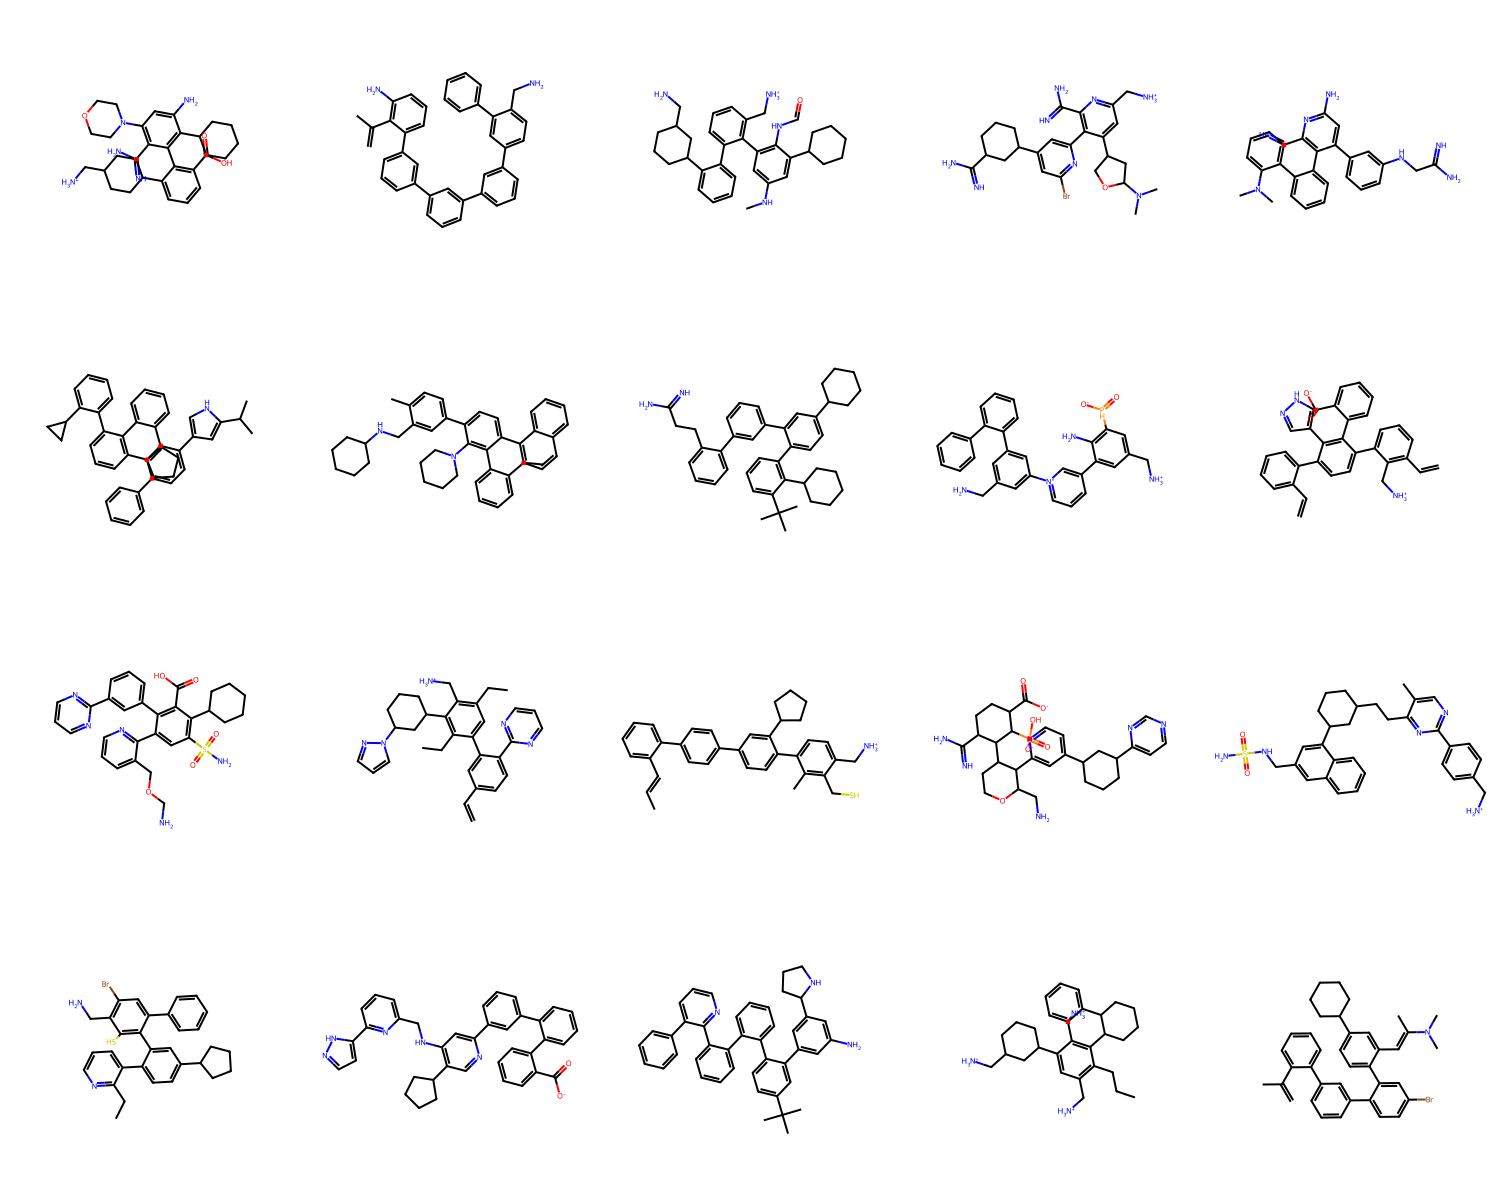

Data size = 10,304
Data size after filtering = 9,326


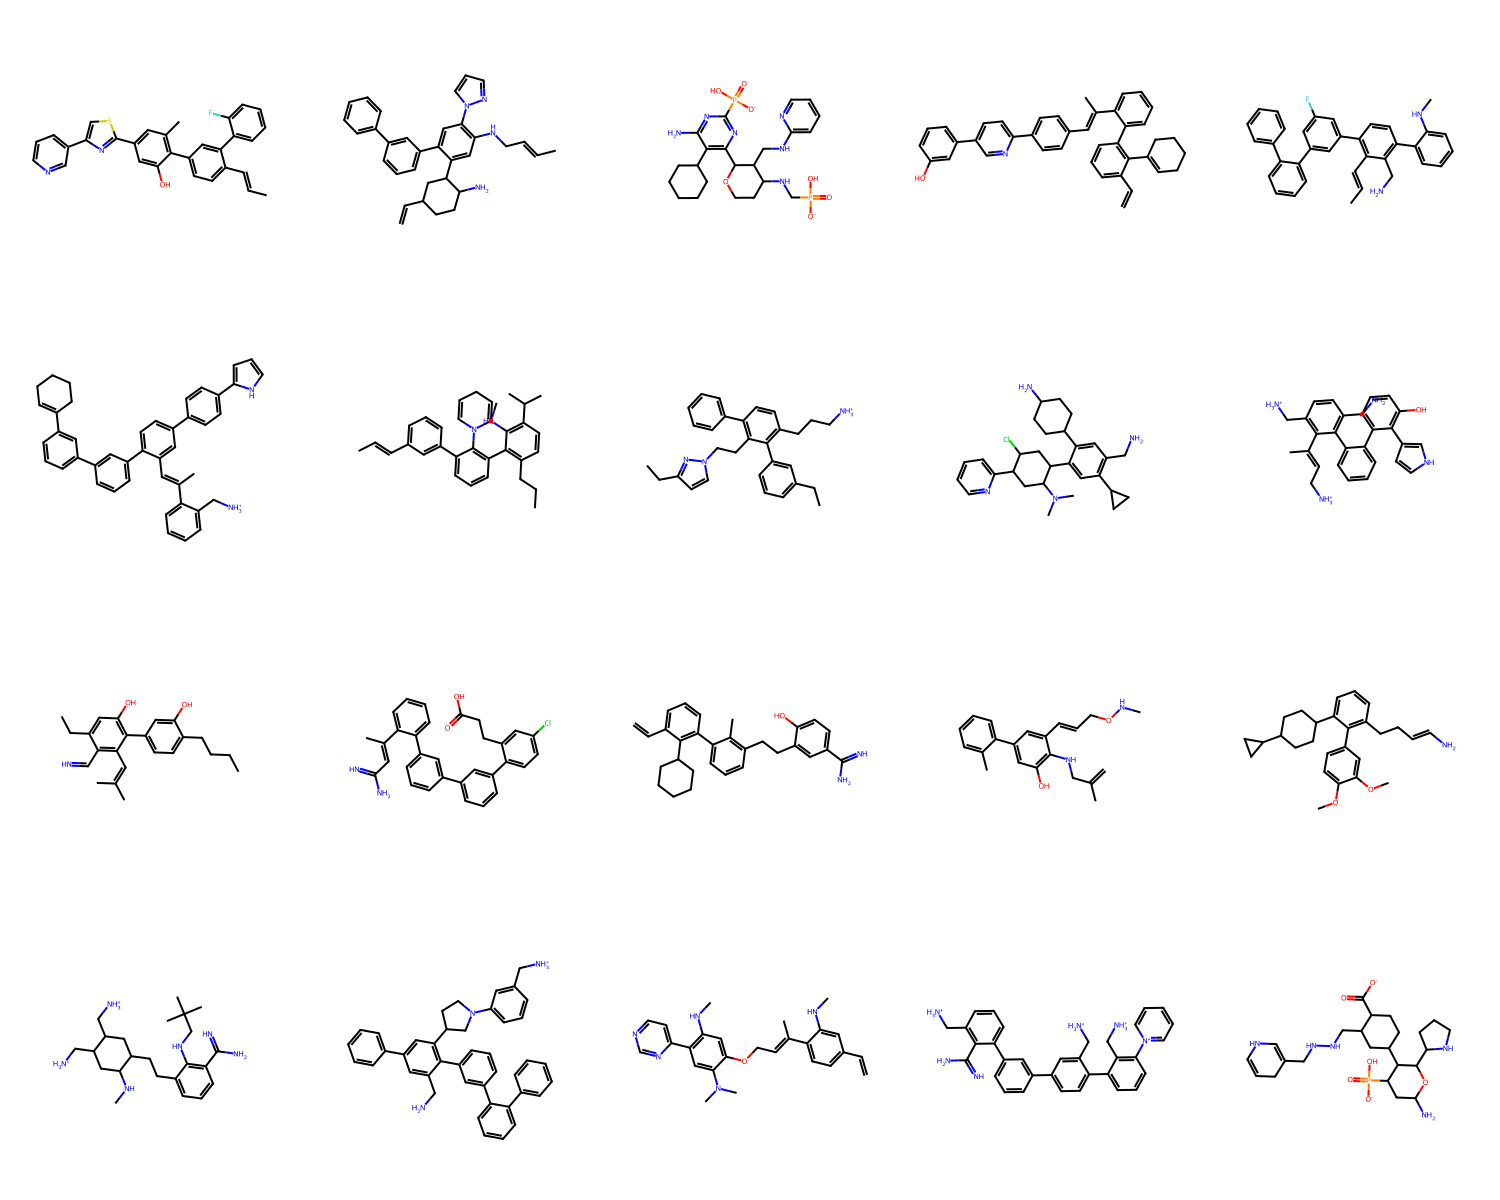

Data size = 10,304
Data size after filtering = 9,854


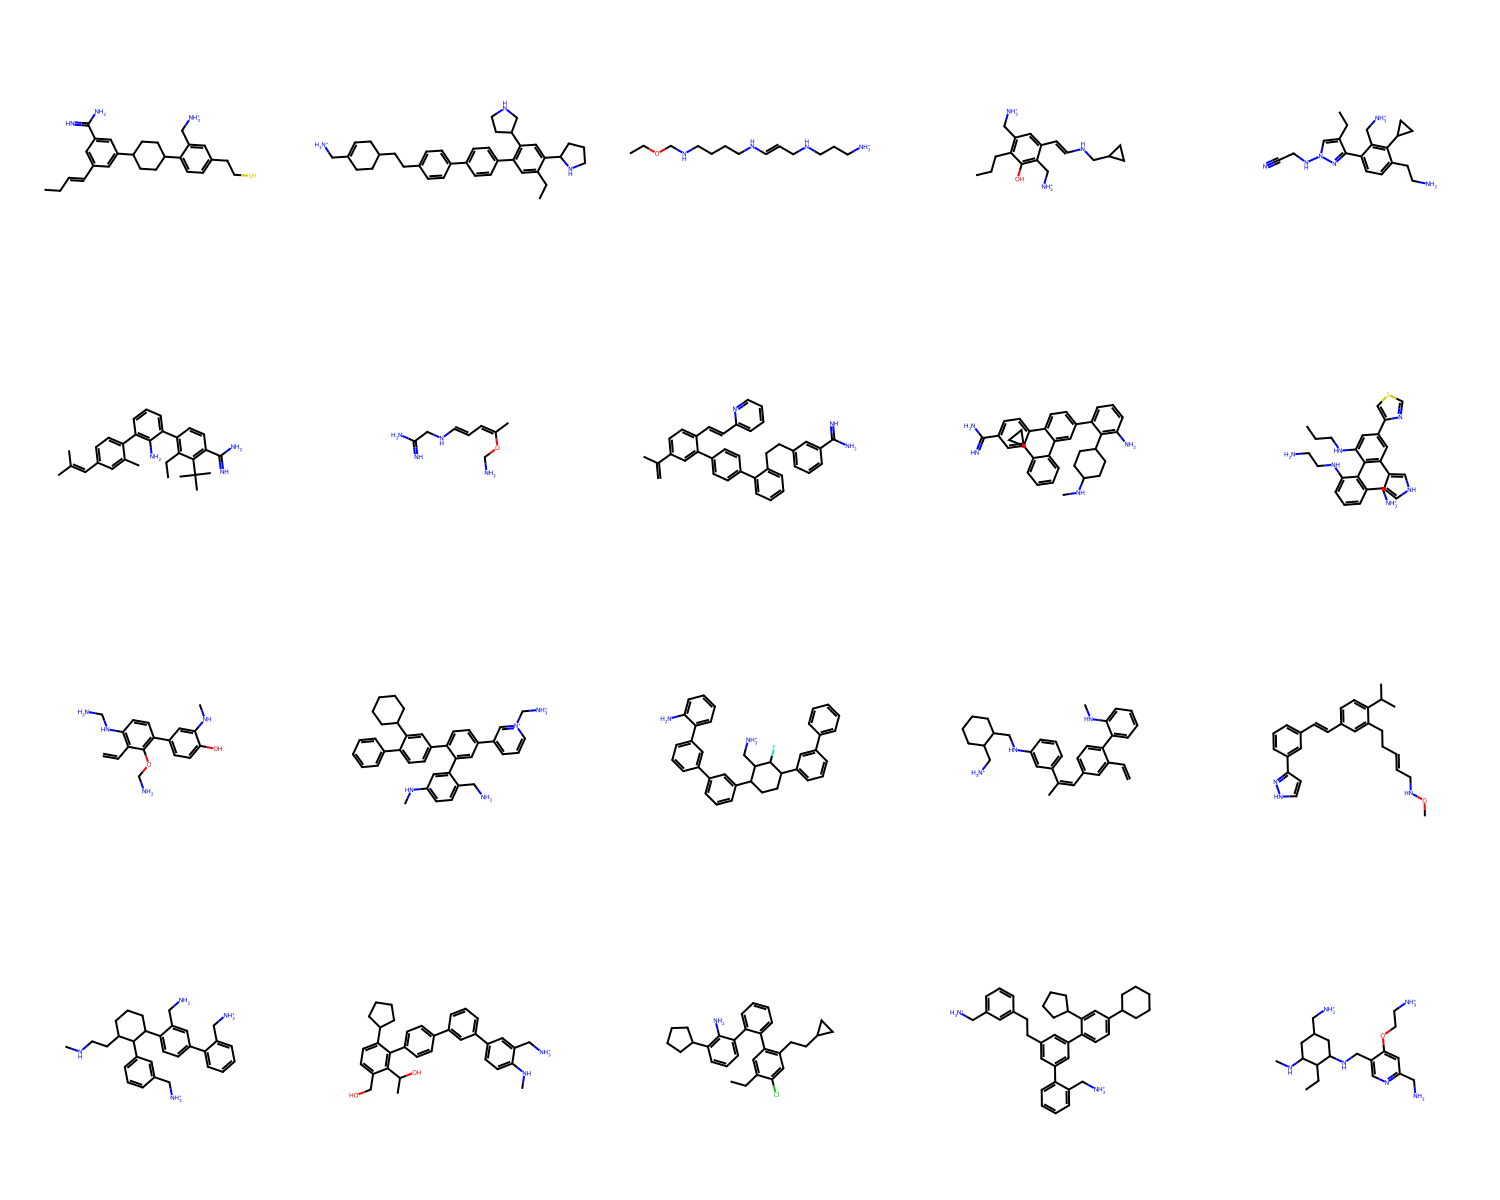

In [47]:
for data in [generated_no_mw, generated_mw_300_1000, generated_mw_200_600]:
    print(f"Data size = {len(data):,}")
    data = data[data["molecular_weight"] < 600]
    print(f"Data size after filtering = {len(data):,}")
    mols = [Chem.MolFromSmiles(smiles) for smiles in data["smiles"].sample(n=20, replace=False, random_state=0)]
    img = Draw.MolsToGridImage(
        mols,
        molsPerRow=5,
        subImgSize=(300, 300),
    )
    display(img)